In [1]:
%load_ext autoreload
%autoreload 2

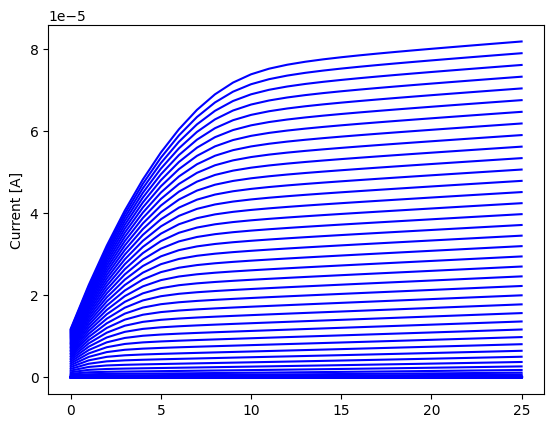

100%|██████████| 10000/10000 [06:15<00:00, 26.65it/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 10_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO 

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)

# raise KeyboardInterrupt

# Get first device data
first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
device = "cuda"

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    train_loader_iter = iter(train_loader)
    for batch_index, dev_data in enumerate(train_loader):
    # for dev in devices_20_data_tensor:
        device_data = dev_data.to(torch.float32)
        device_data = device_data.to(device)
        latent_data = encoder(device_data)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, device_data)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

In [3]:
feature_0_list = []
feature_10_list = []

samples_list = []
for i in range(100):
    samples_list.append([])

for i in range(len(torch_dataset)):
    features_vector_np = torch_dataset[i]
    features_vector_tensor = torch.tensor(features_vector_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent_tensor = encoder(features_vector_tensor)
    latent_numpy =  latent_tensor.cpu().numpy()

    for index in range(len(latent_numpy)):
        samples_list[index].append(latent_numpy[index])

# plt.plot(feature_0_list)
# plt.show()
# plt.plot(feature_10_list)
var_list = []
mean_list = []

var_0_count = 0

for i in range(len(samples_list)):
    var_val = np.var(samples_list[i])
    var_list.append(var_val)
    mean_list.append(np.mean(samples_list[i]))

    if np.isclose(var_val, 0.0):
        var_0_count += 1

for i in range(len(samples_list)):
    print(var_list[i])

0.0
0.0
0.005014746
0.005359311
0.006756273
0.0
0.0
0.005862087
0.0051206173
0.0042850194
0.0054831803
0.005076291
0.0052413684
0.0045291972
0.0
0.005091039
0.005119843
0.0
0.0
0.004468215
0.0
0.005791481
0.0058603645
0.0045396495
0.0
0.0043464703
0.002349341
0.0052431286
0.0
0.0
0.0
0.0
0.0006812137
0.0
0.0060071526
0.0
0.00475892
0.0
0.005835052
0.0056058513
0.0052537285
0.0057054274
0.004942032
0.004877122
0.0
0.0
0.005472
0.0052634757
0.0055591995
0.005280957
0.0053967657
0.0
0.004315728
0.00543029
0.0
0.0
0.0050466573
0.0
0.005698066
0.0059348703
0.0050293924
0.005317513
0.0
0.0
0.0017869602
0.0
0.005112635
0.0
0.0007385851
0.0012382816
0.0048346105
0.0
0.005149812
0.0049425135
0.005489648
0.0050296783
0.005399177
0.004883627
0.00092596083
0.0
0.0
0.0
0.0052628303
0.0015699586
0.00536291
0.0052977884
0.005864148
0.0
0.004845137
0.0011111358
0.0
0.004923174
0.0008715288
0.0
0.0
0.004935495
0.0047387276
0.0019659828
0.005401369
0.0


In [4]:
for i in range(len(samples_list)):
    print(mean_list[i])

0.0
0.0
0.06755372
0.07501147
0.072808266
0.0
0.0
0.07382065
0.06773042
0.05948636
0.07151629
0.07397337
0.06316631
0.06060736
0.0
0.063001
0.06649571
0.0
0.0
0.06714614
0.0
0.07345899
0.080591194
0.06623186
0.0
0.07330911
0.016253147
0.07058177
0.0
0.0
0.0
0.0
0.009233215
0.0
0.08043859
0.0
0.06567881
0.0
0.079985864
0.06974385
0.06756976
0.070556074
0.06743153
0.06780526
0.0
0.0
0.07038811
0.06810617
0.0752623
0.07299531
0.07306379
0.0
0.061058696
0.07644488
0.0
0.0
0.0720917
0.0
0.07011519
0.07459064
0.06632993
0.06889899
0.0
0.0
0.013606835
0.0
0.07447434
0.0
0.009993694
0.013056984
0.063320786
0.0
0.07266119
0.059855662
0.06619182
0.07187161
0.06658106
0.070363306
0.012560976
0.0
0.0
0.0
0.06863596
0.009488329
0.0701607
0.069632486
0.07089676
0.0
0.070055254
0.012406676
0.0
0.0684005
0.011800039
0.0
0.0
0.06902285
0.07715943
0.015066636
0.07209157
0.0


In [5]:
var_0_count

35

In [6]:
for i in range(len(samples_list)):
    print(f"VAR: {var_list[i]}  MEAN: {mean_list[i]}")

VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.005014745984226465  MEAN: 0.06755372136831284
VAR: 0.005359311122447252  MEAN: 0.0750114694237709
VAR: 0.006756273098289967  MEAN: 0.07280826568603516
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.00586208701133728  MEAN: 0.07382065057754517
VAR: 0.005120617337524891  MEAN: 0.06773041933774948
VAR: 0.004285019356757402  MEAN: 0.05948635935783386
VAR: 0.005483180284500122  MEAN: 0.07151629030704498
VAR: 0.005076291039586067  MEAN: 0.07397337257862091
VAR: 0.005241368431597948  MEAN: 0.0631663128733635
VAR: 0.004529197234660387  MEAN: 0.06060735881328583
VAR: 0.0  MEAN: 0.0
VAR: 0.005091038998216391  MEAN: 0.06300099939107895
VAR: 0.005119842942804098  MEAN: 0.06649570912122726
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.00446821516379714  MEAN: 0.06714613735675812
VAR: 0.0  MEAN: 0.0
VAR: 0.005791481118649244  MEAN: 0.07345899194478989
VAR: 0.005860364530235529  MEAN: 0.08059119433164597
VAR: 0.0045396494679152966  MEAN: 0.0662318617105

tensor([1.6231e-09, 3.4207e-09, 7.1129e-09,  ..., 1.2974e-04, 1.3350e-04,
        1.3725e-04], device='cuda:0')


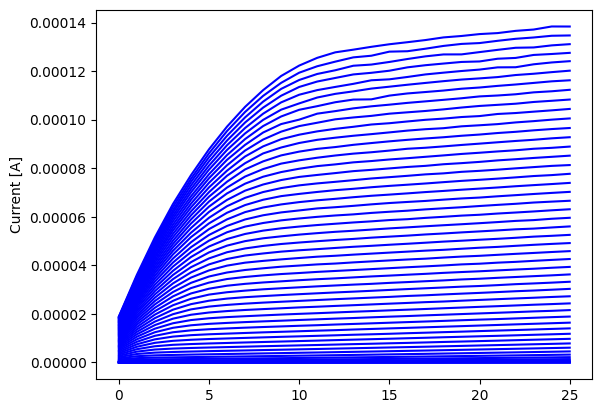

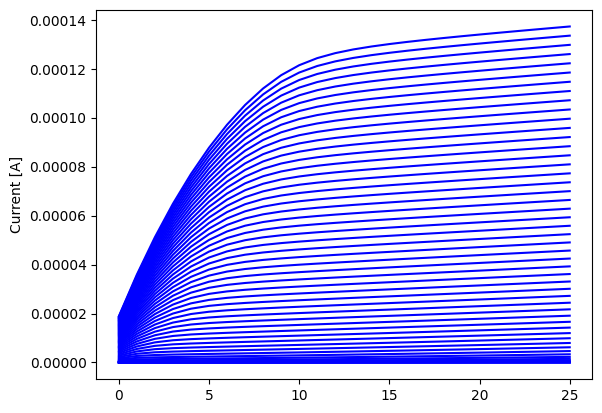

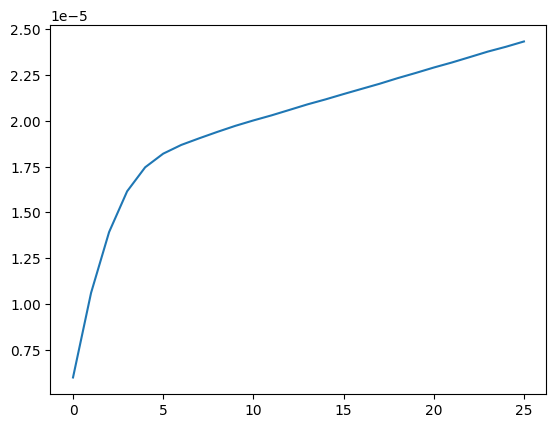

0.00013836804


In [6]:
encoder.eval()
decoder.eval()

data_for_encoder = torch_dataset[15]
data_for_encoder = torch.tensor(data_for_encoder, dtype=torch.float32)
data_for_encoder = data_for_encoder.to(device)
# data_for_encoder = torch.zeros_like(data_for_encoder, dtype=torch.float32)
print(data_for_encoder)

with torch.no_grad():
    encoded_data = encoder(data_for_encoder)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.cpu().numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
separated_curves_1 = get_seperated_curves(data_for_encoder.cpu().numpy(), VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves_1)

plt.plot(separated_curves[20])
plt.show()
print(np.max(decoded_data))

In [ ]:
TIMESTEPS = 40
EPOCHS = 300_000
mlp_model = Mlp(TIMESTEPS)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)
betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger)

In [ ]:
out_tensor = visualize_0(
    first_device_data_tensor,
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder
)

out_numpy_data = out_tensor.numpy()

separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)